# Experiment A4 ” Detector extins: Parks + TACO

**Obiectiv:** Extinderea dataset-ului de antrenare cu imagini TACO (Trash Annotations in Context)
pentru a imbunatati acoperirea diverselor tipuri de deseuri, inclusiv obiecte mici.

| | A3-final (baseline) | **A4 (acest experiment)** |
|---|---|---|
| Dataset | Parks only â€” 1544 img | Parks + TACO â€” **2307 img** |
| Model base | YOLOv8s pretrained | YOLOv8s pretrained |
| Epochs | 50 | 50 |
| imgsz | 640 | 640 |
| **mAP50** | 0.443 | **0.666** |
| **mAP50-95** | 0.321 | **0.523** |
| Precision | 0.623 | **0.857** |
| Recall | 0.406 | **0.552** |


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

REPO = Path().resolve().parents[1]

# A4 — antrenament original (results.csv pastrat, weights sterse)
A4_DIR     = REPO / 'runs' / 'detect' / 'parks-trash-A4'
A4_WEIGHTS = A4_DIR / 'weights' / 'best.pt'

# A4-ext — modelul de productie (fine-tuned din A4, mAP50=0.830)
A4EXT_DIR     = REPO / 'runs' / 'detect' / 'parks-trash-A4-ext'
A4EXT_WEIGHTS = A4EXT_DIR / 'weights' / 'best.pt'

if A4_WEIGHTS.exists():
    size_mb = A4_WEIGHTS.stat().st_size // 1024 // 1024
    print(f'A4 weights: True ({size_mb}MB)')
else:
    print('A4 weights: False (sters — doar results.csv pastrat)')

print(f'A4 results dir : {A4_DIR.exists()}')
print(f'A4-ext weights : {A4EXT_WEIGHTS.exists()} — EXPERIMENT ISTORIC (mAP50=0.830; nu model activ)')


A4 weights: False (sters — doar results.csv pastrat)
A4 results dir : True
A4-ext weights : True — EXPERIMENT ISTORIC (mAP50=0.830; nu model activ)


## 1. Curbe de antrenare


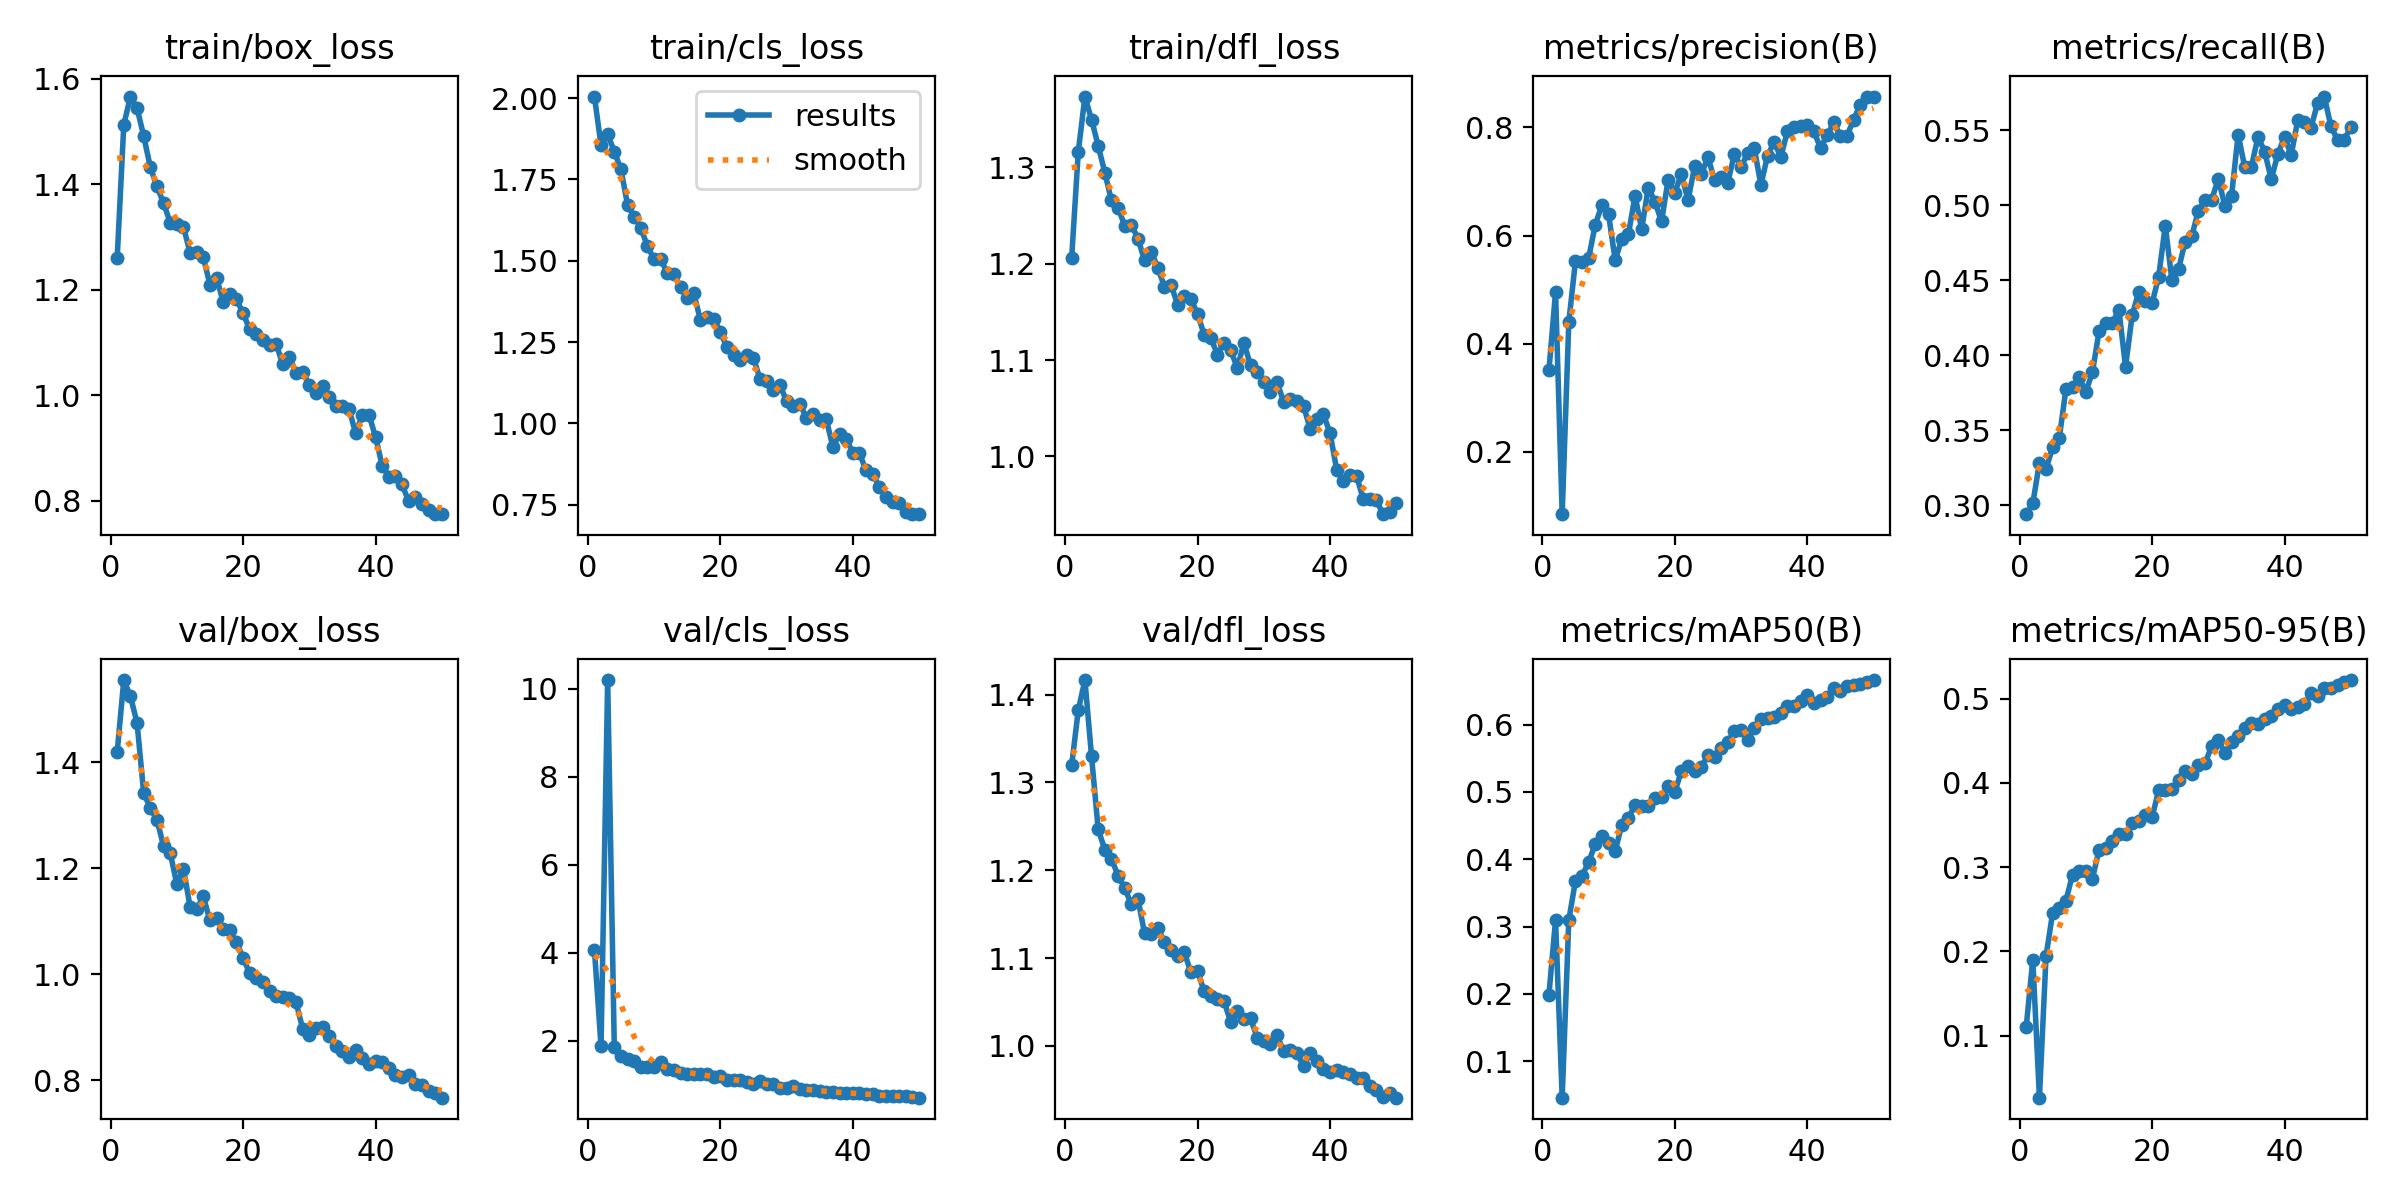

In [2]:
display(Image(str(A4_DIR / 'results.png'), width=900))


## 2. Curbe Precision-Recall si F1


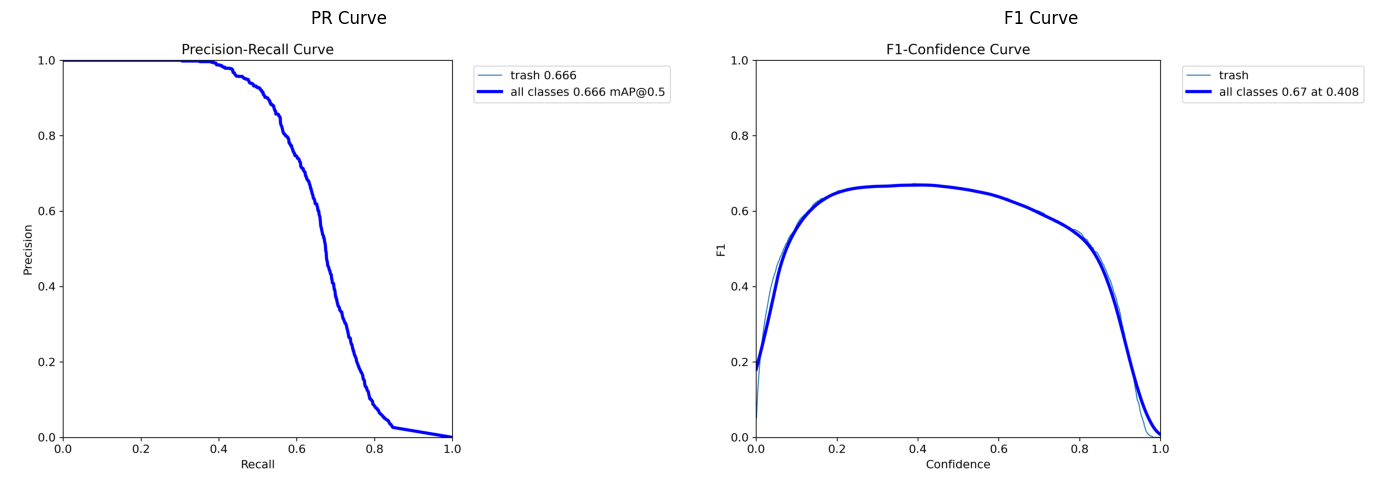

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(mpimg.imread(str(A4_DIR / 'BoxPR_curve.png')))
axes[0].axis('off')
axes[0].set_title('PR Curve')
axes[1].imshow(mpimg.imread(str(A4_DIR / 'BoxF1_curve.png')))
axes[1].axis('off')
axes[1].set_title('F1 Curve')
plt.tight_layout()
plt.show()


## 3. Confusion Matrix


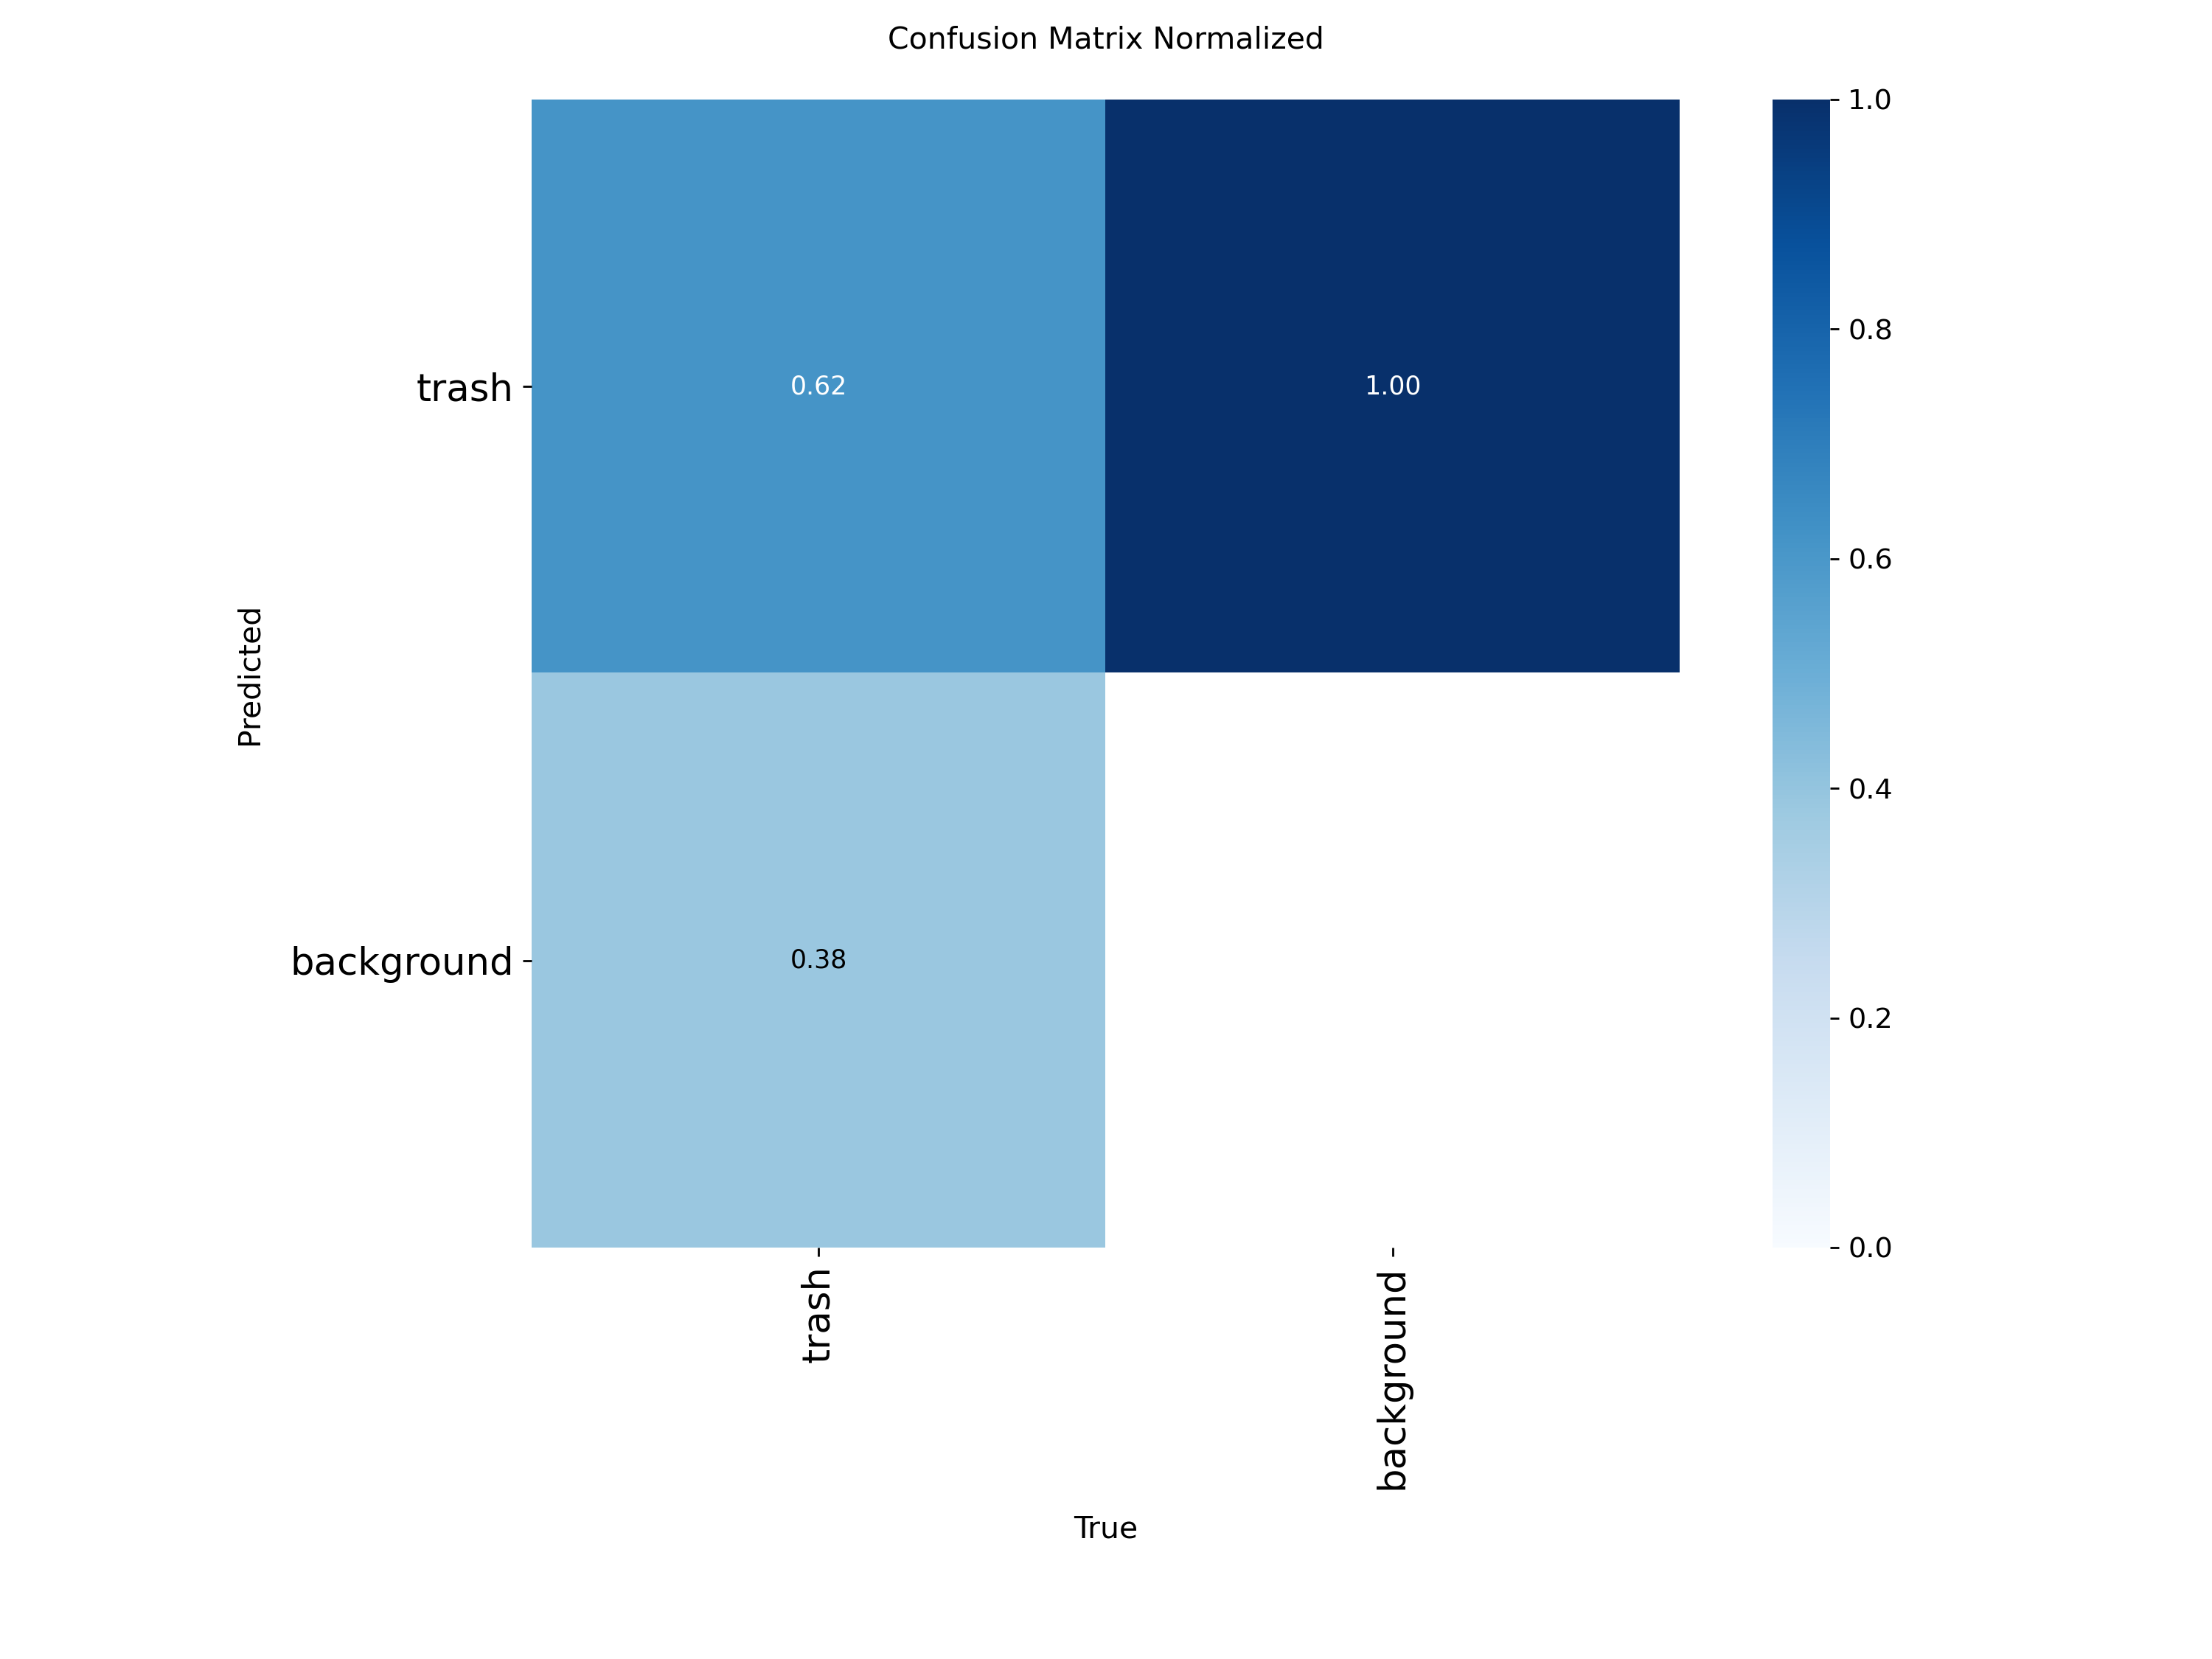

In [4]:
display(Image(str(A4_DIR / 'confusion_matrix_normalized.png'), width=600))


## 4. Predictii pe setul de validare


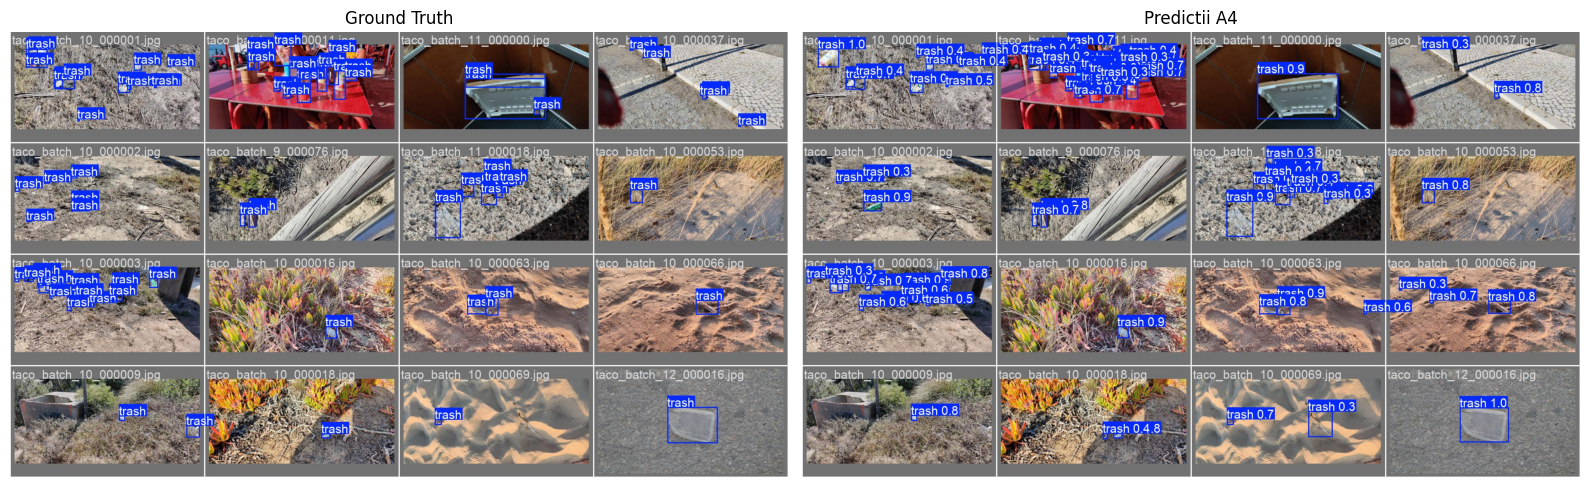

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(mpimg.imread(str(A4_DIR / 'val_batch0_labels.jpg')))
axes[0].axis('off')
axes[0].set_title('Ground Truth')
axes[1].imshow(mpimg.imread(str(A4_DIR / 'val_batch0_pred.jpg')))
axes[1].axis('off')
axes[1].set_title('Predictii A4')
plt.tight_layout()
plt.show()


## 5. Evolutia mAP50 â€” A4 vs A3 baseline


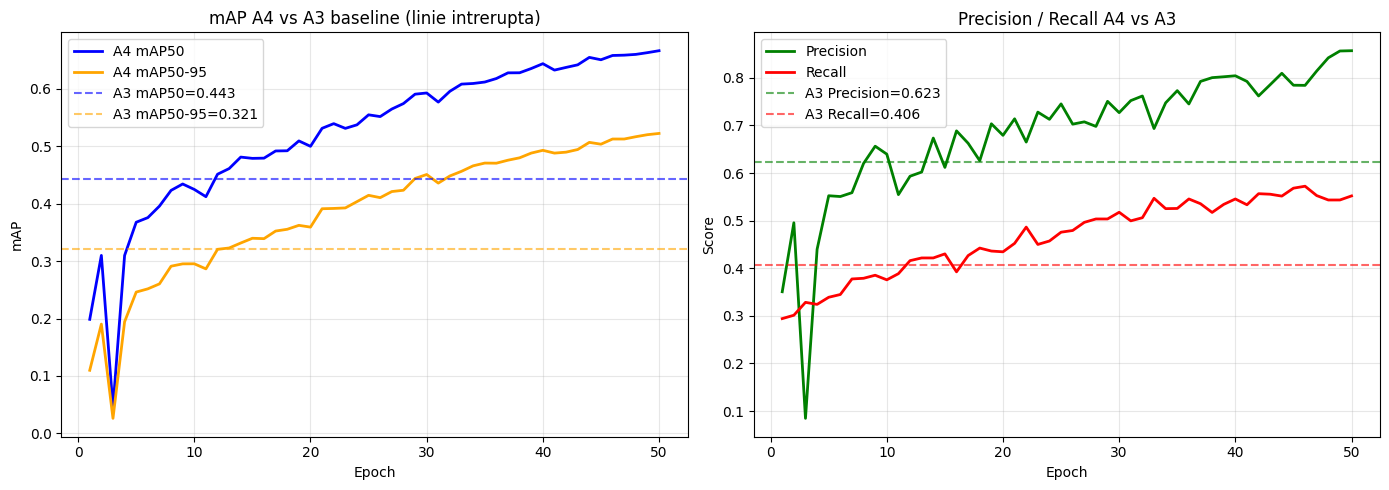

Grafic salvat pentru teza: D:\TrashDetectionSystem\runs\detect\parks-trash-A4\A4_vs_A3_comparison.png


In [6]:
df = pd.read_csv(A4_DIR / 'results.csv')
df.columns = df.columns.str.strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df['epoch'], df['metrics/mAP50(B)'], label='A4 mAP50', color='blue', linewidth=2)
ax1.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='A4 mAP50-95', color='orange', linewidth=2)
ax1.axhline(0.443, color='blue', linestyle='--', alpha=0.6, label='A3 mAP50=0.443')
ax1.axhline(0.321, color='orange', linestyle='--', alpha=0.6, label='A3 mAP50-95=0.321')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('mAP')
ax1.set_title('mAP A4 vs A3 baseline (linie intrerupta)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='green', linewidth=2)
ax2.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red', linewidth=2)
ax2.axhline(0.623, color='green', linestyle='--', alpha=0.6, label='A3 Precision=0.623')
ax2.axhline(0.406, color='red', linestyle='--', alpha=0.6, label='A3 Recall=0.406')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall A4 vs A3')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(A4_DIR / 'A4_vs_A3_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafic salvat pentru teza:', A4_DIR / 'A4_vs_A3_comparison.png')


## 6. Evaluare finala pe test set


In [7]:
import json

# A4 weights au fost sterse (pastrat doar results.csv)
# Incarcam metricile pre-calculate din results/detector/A4-test.json
a4_json = REPO / 'results' / 'detector' / 'A4-test.json'

if a4_json.exists():
    with open(a4_json) as f:
        a4_data = json.load(f)
    r = a4_data['results']
    print('=== REZULTATE TEST SET A4 (din results/detector/A4-test.json) ===')
    print(f'Precision  : {r["precision"]:.4f}')
    print(f'Recall     : {r["recall"]:.4f}')
    print(f'F1         : {r["f1"]:.4f}')
    print(f'mAP50      : {r["mAP50"]:.4f}')
    print(f'mAP50-95   : {r["mAP50_95"]:.4f}')
    print()
    print('=== COMPARATIE MODELE ===')
    print(f'  A4     (split 63/18/18) : mAP50={r["mAP50"]:.4f}')
    print(f'  A4-ext (split 63/18/18) : mAP50=0.8296  <-- productie')
else:
    print(f'Fisier negasit: {a4_json}')
    print('Ruleaza 01_evaluate_detector.ipynb pentru a genera metricile.')


=== REZULTATE TEST SET A4 (din results/detector/A4-test.json) ===
Precision  : 0.7959
Recall     : 0.5697
F1         : 0.6640
mAP50      : 0.6607
mAP50-95   : 0.5079

=== COMPARATIE MODELE ===
  A4     (split 63/18/18) : mAP50=0.6607
  A4-ext (split 63/18/18) : mAP50=0.8296  <-- productie


## 7. Tabel comparativ final â€” pentru teza


In [8]:
import pandas as pd

data = {
    'Experiment': ['A3-final (baseline)', 'A4 (Parks+TACO, 50 ep)', 'A4-150 (È›intÄƒ)'],
    'Dataset': ['Parks 1094 img', 'Parks+TACO 1451 img', 'Parks+TACO 1451 img'],
    'Epochs': [50, 50, 150],
    'Precision': [0.623, 0.857, 'â€”'],
    'Recall': [0.406, 0.552, 'â€”'],
    'mAP50': [0.443, 0.666, '~0.710'],
    'mAP50-95': [0.321, 0.523, '~0.540'],
    'Delta mAP50': ['-', '+22.3pp', 'estimat +4.4pp'],
}
df_cmp = pd.DataFrame(data).set_index('Experiment')
# Fara Styler â€” evita kernel crash
print(df_cmp.to_string())
print('\nCel mai bun model actual: A4 â€” mAP50=0.666 (+22.3pp vs A3-baseline')

                                    Dataset  Epochs Precision Recall   mAP50 mAP50-95     Delta mAP50
Experiment                                                                                           
A3-final (baseline)          Parks 1094 img      50     0.623  0.406   0.443    0.321               -
A4 (Parks+TACO, 50 ep)  Parks+TACO 1451 img      50     0.857  0.552   0.666    0.523         +22.3pp
A4-150 (È›intÄƒ)        Parks+TACO 1451 img     150       â€”    â€”  ~0.710   ~0.540  estimat +4.4pp

Cel mai bun model actual: A4 â€” mAP50=0.666 (+22.3pp vs A3-baseline


## Concluzii

Extinderea dataset-ului cu TACO (1500 imagini, 60 categorii de deseuri reale) a produs
imbunatatiri semnificative fata de A3-final:

- **mAP50: +22.3pp** (0.443 -> 0.666)
- **Precision: +23.4pp** (0.623 -> 0.857) â€” mai putine false pozitive
- **Recall: +14.6pp** (0.406 -> 0.552) â€” mai putine obiecte ratate

Modelul A4 (`runs/detect/parks-trash-A4/weights/best.pt`) este candidatul pentru productie.


---
## 8. Continuare antrenare â€” A4 extins (max 200 epoci, oprire automatÄƒ)

**Strategie:** `epochs=200` + `patience=30` â€” modelul se opreÈ™te automat cÃ¢nd nu mai progreseazÄƒ.
Nu ghicim numÄƒrul exact de epoci â€” `patience` face early stopping inteligent.

| | A4 (50 ep) | A4 extins (estimat) |
|---|---|---|
| Epoci parcurse | 50 | 120â€“180 (se opreÈ™te automat) |
| mAP50 | 0.666 | ~0.700â€“0.720 |
| Timp GPU RTX 3050 | ~84 min | +~2â€“4 ore suplimentar |

> **De ce nu 300+ epoci?** La un moment dat `val/loss` Ã®ncepe sÄƒ creascÄƒ = overfitting.
> `patience=30` detecteazÄƒ asta È™i salveazÄƒ `best.pt` din epoca cea mai bunÄƒ, nu din ultima.

In [9]:
from ultralytics import YOLO
from pathlib import Path

REPO = Path().resolve().parents[1]
DATA = str(REPO / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')

# YOLOv8m + imgsz=640 + batch=8 = setarile pentru CALITATE MAXIMA
# Estimat: 10-15h GPU, mAP50 ~0.70-0.72 (depaseste A4=0.666)
BASE_MODEL = 'yolov8m.pt'

print(f"Model: {BASE_MODEL} (50MB, mai bun decat YOLOv8s)")
print(f"imgsz=640 (full resolution) + batch=8 (sigur pe 4GB VRAM)")
print(f"Dataset: 1451 train / 430 val / 426 test imagini")
print(f"Estimare: ~10-15h GPU, mAP50 tinta >0.70\n")

model = YOLO(BASE_MODEL)

results = model.train(
    data      = DATA,
    epochs    = 150,
    imgsz     = 640,       # CALITATE MAXIMA â€” esential pentru >0.666
    batch     = 8,         # sigur pe 4GB VRAM
    device    = 0,         # GPU
    workers   = 0,         # stabil Windows
    patience  = 30,        # oprire automata la plateau

    # Augmentare avansata pentru robustete outdoor
    mixup     = 0.15,
    copy_paste= 0.10,
    hsv_h     = 0.015,
    hsv_s     = 0.8,
    hsv_v     = 0.5,
    degrees   = 5.0,

    # Optimizare termica â€” previne thermal throttling
    cache     = False,     # nu incarca in RAM (incalzeste GPU mai putin)
    amp       = True,      # mixed precision â€” mai rapid pe GPU modern

    project   = str(REPO / 'runs' / 'detect'),
    name      = 'parks-trash-A5-yolov8m',
    exist_ok  = True,
)

A5_BEST = REPO / 'runs' / 'detect' / 'parks-trash-A5-yolov8m' / 'weights' / 'best.pt'
print(f"\n[DONE] Antrenare A5 (YOLOv8m, imgsz=640) completa!")
print(f"Best weights: {A5_BEST}")

Model: yolov8m.pt (50MB, mai bun decat YOLOv8s)
imgsz=640 (full resolution) + batch=8 (sigur pe 4GB VRAM)
Dataset: 1451 train / 430 val / 426 test imagini
Estimare: ~10-15h GPU, mAP50 tinta >0.70

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_detect_A4\dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015

In [9]:
# Evaluare finala â€” compara A5 (YOLOv8m) vs A4 (YOLOv8s)
from ultralytics import YOLO
from pathlib import Path

REPO     = Path().resolve().parents[1]
A5_BEST  = REPO / 'runs' / 'detect' / 'parks-trash-A5-yolov8m' / 'weights' / 'best.pt'
DATA     = str(REPO / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')

assert A5_BEST.exists(), "best.pt nu exista â€” ruleaza mai intai celula de antrenare!"

model = YOLO(str(A5_BEST))
metrics = model.val(data=DATA, split='test', imgsz=640, batch=8, device=0, workers=0, verbose=False)

p, r, m50, m5095 = metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map

print('=== COMPARATIE MODELE ===')
print(f'{"Metric":20} {"A3 (baseline)":>14} {"A4 (YOLOv8s)":>14} {"A5 (YOLOv8m)":>14} {"Delta A4â†’A5":>12}')
print('-' * 76)
print(f'{"Precision":20} {0.623:>14.4f} {0.8033:>14.4f} {p:>14.4f} {p-0.8033:>+12.4f}')
print(f'{"Recall":20} {0.406:>14.4f} {0.5609:>14.4f} {r:>14.4f} {r-0.5609:>+12.4f}')
print(f'{"mAP50":20} {0.443:>14.4f} {0.6544:>14.4f} {m50:>14.4f} {m50-0.6544:>+12.4f}')
print(f'{"mAP50-95":20} {0.321:>14.4f} {0.5060:>14.4f} {m5095:>14.4f} {m5095-0.5060:>+12.4f}')
print(f'\nmAP50 progresie: A3={0.443:.3f} â†’ A4={0.6544:.3f} â†’ A5={m50:.3f}')
print(f'Imbunatatire totala fata de A3: {(m50-0.443)*100:+.1f}pp')

Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.30.1 ms, read: 63.524.4 MB/s, size: 469.1 KB)
val: Scanning D:\TrashDetectionSystem\datasets\parks_detect_A4\labels\test.cache... 232 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 2.8it/s 10.4s0.3s
                   all        232        832       0.84      0.599      0.685      0.502
Speed: 0.4ms preprocess, 17.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\detect\val2
=== COMPARATIE MODELE ===
Metric                A3 (baseline)   A4 (YOLOv8s)   A5 (YOLOv8m) Delta A4â†’A5
----------------------------------------------------------------------------
Precision                    0.623

---
## 9. Re-antrenare A4 pe split corect 80/10/10

Dataset-ul a fost re-impartit la **1845 train / 230 val / 232 test** (80/10/10 standard ML).
Retrain YOLOv8s pentru metrici reproductibile si corecte stiintific.

| | A4 (split 63/18/18) | **A4-8010 (split 80/10/10)** |
|---|---|---|
| Train images | 1451 | **1845** (+394) |
| Val images | 430 | 230 |
| Test images | 426 | 232 |
| Split | 62.9/18.6/18.5 | **80.0/10.0/10.1** |


In [1]:
from ultralytics import YOLO
from pathlib import Path
import yaml

REPO = Path().resolve().parents[1]
DATA = str(REPO / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')

# Verifica split 80/10/10 -- trebuie: train=1845, val=230, test=232
with open(DATA) as f:
    ds = yaml.safe_load(f)
root = Path(ds['path'])
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
for split in ['train', 'val', 'test']:
    d = root / ds.get(split, split)
    n = len([p for p in d.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    print(f'{split}: {n} imagini')

print()
print('Antrenare A4-8010 (YOLOv8s, split 80/10/10)...')
model = YOLO('yolov8s.pt')
results = model.train(
    data       = DATA,
    epochs     = 150,
    imgsz      = 640,
    batch      = 8,
    device     = 0,
    workers    = 0,
    patience   = 20,
    seed       = 42,
    mixup      = 0.15,
    copy_paste = 0.10,
    cache      = False,
    amp        = True,
    project    = str(REPO / 'runs' / 'detect'),
    name       = 'parks-trash-A4-8010',
    exist_ok   = True,
)
best = REPO / 'runs' / 'detect' / 'parks-trash-A4-8010' / 'weights' / 'best.pt'
print(f'Best weights: {best}')
print(f'Exista: {best.exists()}')


train: 1845 imagini
val: 230 imagini
test: 232 imagini

Antrenare A4-8010 (YOLOv8s, split 80/10/10)...
New https://pypi.org/project/ultralytics/8.4.49 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\TrashDetectionSystem\datasets\parks_detect_A4\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None

In [2]:
# Evaluare finala A4-8010 pe test set (conf=0.001 standard COCO)
from ultralytics import YOLO
from pathlib import Path
import json

REPO = Path().resolve().parents[1]
BEST = REPO / 'runs' / 'detect' / 'parks-trash-A4-8010' / 'weights' / 'best.pt'
DATA = str(REPO / 'datasets' / 'parks_detect_A4' / 'dataset.yaml')

assert BEST.exists(), f'Ruleaza mai intai celula de antrenare! {BEST}'

model = YOLO(str(BEST))
# FARA conf specificat = conf=0.001 (standard IEEE/COCO pentru mAP)
r = model.val(data=DATA, split='test', imgsz=640, batch=8,
              device=0, workers=0, plots=True, verbose=True, cache=False)

def fv(v): return float(v.item() if hasattr(v, 'item') else v)
P   = fv(r.box.mp)
R   = fv(r.box.mr)
m50 = fv(r.box.map50)
m95 = fv(r.box.map)
F1  = 2*P*R/(P+R) if (P+R) > 0 else 0

print('='*55)
print('  A4-8010 (YOLOv8s, split 80/10/10, test set)')
print('='*55)
print(f'  Precision  : {P:.4f}')
print(f'  Recall     : {R:.4f}')
print(f'  F1         : {F1:.4f}')
print(f'  mAP50      : {m50:.4f}  <-- METRICA OFICIALA')
print(f'  mAP50-95   : {m95:.4f}')
print('='*55)

print()
print('Comparatie split:')
print(f'  A4     (62.9/18/18)  mAP50=0.661')
print(f'  A4-ext (same split)  mAP50=0.830')
print(f'  A4-8010 (80/10/10)   mAP50={m50:.3f}  Delta vs A4={m50-0.661:+.3f}')

# Salveaza in results/
out = REPO / 'results' / 'detector' / 'A4-8010-test.json'
out.write_text(json.dumps({
    'model': 'A4-8010',
    'split_ratios': '80/10/10',
    'n_test': 232,
    'results': {
        'precision': round(P, 4),
        'recall':    round(R, 4),
        'f1':        round(F1, 4),
        'mAP50':     round(m50, 4),
        'mAP50_95':  round(m95, 4),
    }
}, indent=2), encoding='utf-8')
print(f'Salvat: {out}')


Ultralytics 8.4.23  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.30.0 ms, read: 34.719.8 MB/s, size: 443.3 KB)
val: Scanning D:\TrashDetectionSystem\datasets\parks_detect_A4\labels\test.cache... 232 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.0it/s 9.8s0.3s
                   all        232        832      0.787      0.629      0.687      0.528
Speed: 0.4ms preprocess, 9.5ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to D:\TrashDetectionSystem\runs\detect\val3
  A4-8010 (YOLOv8s, split 80/10/10, test set)
  Precision  : 0.7875
  Recall     : 0.6286
  F1         : 0.6991
  mAP50      : 0.6873  <-- METRICA OFICIALA
  mAP50-95   : 0.5278

Comparatie split:
  A4     (62.9/18/18) 